# SMS Spam Detection

This project compares five spam detection approaches across multiple datasets. In addition to evaluating models on their original datasets, the experiments investigate cross-dataset generalization, training-data size, realistic class imbalance, inference speed, model size, and classification errors.

Four datasets are used: UCI SMS Spam Collection, Turkish SMS Collection, YouTube Spam Collection, and Enron Spam. The SMS datasets represent the primary task domain, while YouTube comments and Enron emails introduce different text domains to evaluate how well the models generalize beyond the type of data on which they are trained.

Reusable functionality for dataset loading, preprocessing, metrics, experiments, and model implementations is kept in the `src/` directory. This notebook documents the experimental workflow, including dataset validation, model development, evaluation, and visualization of the results.

## 0. Google Colab Environment Setup

The project is run in Google Colab so that the transformer-based models can use a GPU during fine-tuning, as recommended in the assignment.

The project repository is cloned into the Colab runtime, the GPU environment is verified, and the raw datasets are restored from Google Drive before running the data preparation and experiments.

In [1]:
import os

# Clone the repository only if it is not already present.
if not os.path.exists("/content/spam-detection"):
    !git clone https://github.com/ddolapcioglu24/spam-detection.git

# Move into the project directory.
%cd /content/spam-detection

Cloning into 'spam-detection'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 91 (delta 45), reused 54 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (91/91), 253.45 KiB | 1.53 MiB/s, done.
Resolving deltas: 100% (45/45), done.
/content/spam-detection


### 0.1 GPU Verification

A GPU-enabled Colab runtime is used for transformer fine-tuning when available. CUDA availability and the detected GPU are checked before running the transformer-based experiments.

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


### 0.2 Python Environment Check

The main Python packages used by the project are checked to confirm that the Colab environment can load the libraries required by the data pipeline, transformer models, SVM, and fastText implementation.

Since fastText is not included in the default Colab runtime, it is installed explicitly before the environment is checked.

In [3]:
# Install fastText, which is not included in the default Colab runtime.
!pip install -q fasttext==0.9.3

# Import the main dependencies and report their versions.
import numpy as np
import pandas as pd
import sklearn
import transformers
import datasets as hf_datasets
import accelerate
import fasttext

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("PyTorch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", hf_datasets.__version__)
print("accelerate:", accelerate.__version__)
print("fastText imported successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 3.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
NumPy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.6.1
PyTorch: 2.11.0+cu128
transformers: 5.13.1
datasets: 4.0.0
accelerate: 1.14.0
fastText imported successfully


### 0.3 Dataset Setup

The raw datasets are excluded from the Git repository. To avoid uploading the same files again after every Colab runtime restart, the compressed raw dataset directory is stored persistently in Google Drive.

Google Drive is mounted in the Colab runtime, and the archive is extracted into the project directory so that the dataset paths match those defined in `src/config.py`.

In [4]:
from google.colab import drive

# Mount Google Drive to access the stored raw datasets.
drive.mount("/content/drive")

# Extract the raw datasets into the project directory.
!unzip -oq \
    "/content/drive/MyDrive/spam-detection/raw_data.zip" \
    -d /content/spam-detection

Mounted at /content/drive


## 1. Dataset Preparation and Validation

Four datasets from different languages and domains are used:

1. **UCI SMS Spam Collection** — English SMS messages.
2. **Turkish SMS Collection** — Turkish SMS messages.
3. **UCI YouTube Spam Collection** — YouTube comments from a different text domain.
4. **Enron Spam** — English emails from a different communication domain.

Before training any model, the datasets are inspected for their size, class distribution, missing values, internal duplicates, and overlap with the other datasets. Cross-dataset overlap is checked after normalizing the text by lowercasing, removing punctuation, and collapsing extra whitespace.

In [5]:
# Import reusable dataset utilities.
from src.data import (
    load_uci_sms,
    load_turkish_sms,
    load_youtube_spam,
    load_enron_spam,
    normalize_text,
    get_duplicate_stats,
    get_dataset_overlap,
)

### 1.1 Loading the Datasets

Each dataset has its own loading function in `src/data.py`. Although the original files have different formats and column names, every loader returns the same two-column representation:

- `label`: `ham` or `spam`
- `text`: the original message or comment

Using a common representation allows the same evaluation and modeling code to be reused across all four datasets.

In [6]:
# Load all four datasets using their dedicated loaders.
uci = load_uci_sms()
turkish = load_turkish_sms()
youtube = load_youtube_spam()
enron = load_enron_spam()

# Keep datasets together for reusable analysis.
datasets = {
    "UCI SMS": uci,
    "Turkish SMS": turkish,
    "YouTube Spam": youtube,
    "Enron Spam": enron,
}

# Preview the standardized UCI dataset.
uci.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### 1.2 Dataset Summary

Before modeling, we verify the size and class distribution of each dataset. This is especially important because the proportion of spam messages differs substantially across the four datasets.

We also check for missing labels or text entries to make sure the datasets are ready for later experiments.

In [7]:
# Build a summary of size, class distribution, and missing values.
summary_rows = []

for name, df in datasets.items():
    spam_count = (df["label"] == "spam").sum()
    ham_count = (df["label"] == "ham").sum()

    summary_rows.append({
        "dataset": name,
        "total": len(df),
        "ham": ham_count,
        "spam": spam_count,
        "spam_ratio": spam_count / len(df),
        "missing_text": df["text"].isna().sum(),
        "missing_label": df["label"].isna().sum(),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,dataset,total,ham,spam,spam_ratio,missing_text,missing_label
0,UCI SMS,5572,4825,747,0.134063,0,0
1,Turkish SMS,4751,2215,2536,0.533782,0,0
2,YouTube Spam,1956,951,1005,0.513804,0,0
3,Enron Spam,33716,16545,17171,0.509283,0,0


#### Dataset Summary Interpretation

The four datasets differ substantially in both size and class distribution. UCI SMS contains 5,572 messages with a spam ratio of approximately 13.4%, while Turkish SMS, YouTube Spam, and Enron Spam are much more balanced, with spam ratios close to 50%.

Enron is considerably larger than the other datasets, containing 33,716 messages, whereas YouTube Spam is the smallest with 1,956 messages.

No missing text or label values are present in any of the four datasets. This confirms that no additional missing-value handling is required before the later duplicate analysis, splitting, and modeling steps.


### 1.3 Duplicate Analysis

Duplicate messages can affect the reliability of model evaluation, especially if identical or equivalent messages appear in both the training and test sets.

For duplicate detection, message text is normalized by converting it to lowercase, removing punctuation, and collapsing extra whitespace. We first measure repeated messages within each dataset and then check for overlap between different datasets.

In [8]:
# Calculate duplicate statistics within each dataset.
duplicate_rows = []

for name, df in datasets.items():
    stats = get_duplicate_stats(df)

    duplicate_rows.append({
        "dataset": name,
        **stats,
    })

duplicate_df = pd.DataFrame(duplicate_rows)
duplicate_df

,dataset,total_messages,unique_messages,duplicate_rows
0,UCI SMS,5572,5131,441
1,Turkish SMS,4751,4696,55
2,YouTube Spam,1956,1713,243
3,Enron Spam,33716,30101,3615


#### Duplicate Analysis Interpretation

Duplicate frequency varies considerably across the four datasets. Turkish SMS contains relatively few repeated messages, while UCI SMS and YouTube Spam contain more noticeable duplication. Enron has the largest absolute number of duplicate rows, with 3,615 messages becoming duplicates after normalization.

These duplicates are important for later evaluation because equivalent messages should not be allowed to appear in both the training and test sets. The train/test splitting procedure will therefore account for normalized duplicates to reduce the risk of data leakage.


#### Additional Duplicate Check for Enron

Because Enron contains the largest absolute number of duplicate rows, its duplicate structure is examined in more detail. To determine whether the detected duplicates are already present in the original data or are introduced by text normalization, exact-text duplicates are compared with duplicates after normalization.


In [9]:
# Compare original and normalized duplicate counts.
print("Exact duplicate texts:", enron["text"].duplicated().sum())

normalized_enron = enron["text"].apply(normalize_text)
print("Normalized duplicate texts:", normalized_enron.duplicated().sum())

Exact duplicate texts: 3222
Normalized duplicate texts: 3615


The results show that 3,222 duplicate messages already exist as exact duplicates in the original Enron data, while 3,615 duplicates are detected after normalization. Normalization therefore introduces 393 additional duplicate rows beyond those that are already exact copies.

These duplicates are not removed at this stage. Their handling will be considered during train/test splitting to prevent the same or equivalent messages from appearing in both sets and causing data leakage.

### 1.4 Cross-Dataset Overlap

In addition to duplicates within each dataset, we check whether the same normalized messages appear across different datasets.

A large overlap would make cross-dataset evaluation less meaningful because the test dataset could contain messages already seen in the training dataset.

In [10]:
from itertools import combinations

# Calculate overlap for every pair of datasets.
overlap_rows = []

for (name1, df1), (name2, df2) in combinations(datasets.items(), 2):
    overlap = get_dataset_overlap(df1, df2)

    overlap_rows.append({
        "dataset_1": name1,
        "dataset_2": name2,
        "overlap": len(overlap),
    })

overlap_df = pd.DataFrame(overlap_rows)
overlap_df

,dataset_1,dataset_2,overlap
0,UCI SMS,Turkish SMS,2
1,UCI SMS,YouTube Spam,1
2,UCI SMS,Enron Spam,0
3,Turkish SMS,YouTube Spam,1
4,Turkish SMS,Enron Spam,0
5,YouTube Spam,Enron Spam,0


### 1.5 Dataset Validation Summary

The datasets differ substantially in both size and class distribution. UCI SMS contains 5,572 messages with a spam ratio of 13.41%, Turkish SMS contains 4,751 messages with a spam ratio of 53.38%, YouTube Spam contains 1,956 comments with a spam ratio of 51.38%, and Enron contains 33,716 emails with a spam ratio of 50.93%. No missing text or label values were found after loading.

Cross-dataset overlap after normalization is very small. Only two messages overlap between UCI SMS and Turkish SMS, one between UCI SMS and YouTube Spam, and one between Turkish SMS and YouTube Spam. No normalized messages from Enron overlap with any of the other datasets.

Internal duplicate analysis revealed 441 duplicate rows in UCI SMS, 55 in Turkish SMS, 243 in YouTube Spam, and 3,615 in Enron after normalization. An additional check showed that 3,222 Enron messages are already exact duplicates before normalization, while normalization introduces 393 additional duplicate rows.

The very low cross-dataset overlap reduces the risk that later transfer experiments are influenced by identical messages appearing in both the training and test datasets.

## 2. Model Development

The project compares five spam detection approaches. Although the models use different text representations and learning algorithms, they follow a common interface so that the same experimental and evaluation code can be reused across all models.

Each model provides:

- `fit(texts, labels)` to train the model.
- `predict_proba(texts)` to produce spam probabilities or comparable prediction scores for evaluation and threshold selection.

The transformer-based models share common functionality for tokenization, batching, device selection, fine-tuning, and prediction through a reusable base implementation in `src/models/transformer_base.py`. Individual transformer model classes specify the pretrained model and its configuration while reusing this common training and inference pipeline.

The model implementations are kept in `src/models/`, while this notebook documents their development, validation, and later experimental comparison.

In [11]:
import numpy as np

# Import the five spam detection models.
from src.models.bert_base import BERTBaseModel
from src.models.distilbert import DistilBERTModel
from src.models.xlm_roberta import XLMRoBERTaModel
from src.models.svm import TfidfSVMModel
from src.models.fasttext_model import FastTextModel

### 2.1 BERT Base Uncased

The first transformer model is `bert-base-uncased`, a pretrained English BERT model. It will be fine-tuned for binary spam classification by adding a classification layer with two output classes: ham and spam.

The model receives raw message text, tokenizes it using the corresponding BERT tokenizer, and learns to distinguish between ham and spam during fine-tuning. Its implementation follows the common `fit(texts, labels)` and `predict_proba(texts)` interface defined for all models in this project.

Since transformer fine-tuning is computationally expensive, the main experiments are run in a GPU-enabled Colab environment.

#### Sequence Length Selection

BERT processes text as sequences of tokens with a fixed maximum length. A larger maximum length preserves more information from long messages but also increases memory usage and computation time.

Since the datasets contain both short SMS messages and longer emails, their token-length distributions are examined before choosing the maximum sequence length.

In [12]:
# Load the pretrained BERT model and tokenizer.
bert_model = BERTBaseModel()

# Measure token lengths without padding or truncation.
length_rows = []

for name, df in datasets.items():
    lengths = [
        len(bert_model.tokenizer.encode(text, add_special_tokens=True))
        for text in df["text"]
    ]

    length_rows.append({
        "dataset": name,
        "median": int(np.median(lengths)),
        "90th_percentile": int(np.percentile(lengths, 90)),
        "95th_percentile": int(np.percentile(lengths, 95)),
        "99th_percentile": int(np.percentile(lengths, 99)),
        "max": int(np.max(lengths)),
    })

length_df = pd.DataFrame(length_rows)
length_df

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] Token i

,dataset,median,90th_percentile,95th_percentile,99th_percentile,max
0,UCI SMS,20,49,55,80,238
1,Turkish SMS,55,98,106,116,206
2,YouTube Spam,15,71,110,175,699
3,Enron Spam,180,737,1107,2219,7688


The token-length distributions differ substantially across the datasets. SMS messages and YouTube comments are generally short, with 99% of their messages remaining below 256 tokens. Enron emails are considerably longer: the median length is 180 tokens and the 90th percentile reaches 737 tokens. Since BERT supports sequences of at most 512 tokens, a substantial portion of the longer Enron emails cannot be represented in full.

A maximum sequence length of 256 tokens is selected as a practical compromise between information retention and computational cost. It covers nearly all messages in the three shorter-text datasets and exceeds the median Enron email length. Longer messages will be truncated during BERT fine-tuning and prediction. Increasing the length to 512 would preserve more Enron content but would increase memory and computation requirements while still truncating many of the longer emails.

The tokenizer warning produced during this analysis is expected because token lengths are intentionally measured without truncation; these untruncated sequences are not passed through BERT during this step.


#### Implementation Sanity Check

Before using the BERT model in the main experiments, a small sanity check is performed to verify that the complete model pipeline works as expected.

The purpose of this test is not to evaluate classification performance. Instead, it checks whether the model can successfully:

- receive raw text and labels,
- tokenize and batch the messages,
- perform a training step through `fit()`,
- generate spam probabilities through `predict_proba()`.

To keep this functional test lightweight, a very small artificial dataset is used and the model is trained for only one epoch with reduced sequence length and batch size. These temporary settings do not replace the default experiment configuration defined in `src/config.py`.

In [13]:
# Small artificial dataset used only to test the model pipeline.
sanity_texts = [
    "Hey, are we still meeting tomorrow?",
    "Can you send me the lecture notes?",
    "Congratulations! You won a free prize. Claim now!",
    "URGENT! Click here to receive your cash reward!",
]

sanity_labels = [
    "ham",
    "ham",
    "spam",
    "spam",
]

# Use lightweight settings so that the sanity check runs quickly.
sanity_model = BERTBaseModel(
    max_length=64,
    batch_size=2,
    epochs=1,
)

# Verify that the training pipeline runs successfully.
sanity_model.fit(
    sanity_texts,
    sanity_labels,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/1 - Average Loss: 0.6836


In [14]:
# Test inference on two previously unseen example messages.
sanity_test_texts = [
    "Are you coming to class today?",
    "WIN A FREE CASH PRIZE! CLICK NOW!",
]

# Generate the spam probability for each message.
sanity_probabilities = sanity_model.predict_proba(
    sanity_test_texts
)

print("Spam probabilities:", sanity_probabilities)
print("Output shape:", sanity_probabilities.shape)

Spam probabilities: [0.3483992  0.42645365]
Output shape: (2,)


The sanity check completed successfully. The model was able to perform both training and inference without errors, and `predict_proba()` returned one spam probability for each input message, resulting in an output shape of `(2,)`.

The probability values themselves are not interpreted as measures of model performance because the model was fine-tuned using only four artificial messages for a single epoch. The purpose of this test is only to verify that the implementation works correctly before running the actual experiments.

### 2.2 DistilBERT

The second transformer model is DistilBERT, a smaller and faster model derived from BERT through knowledge distillation. DistilBERT retains much of the language understanding capability of BERT while reducing the number of transformer layers and computational requirements.

For spam detection, the pretrained `distilbert-base-uncased` model will be fine-tuned for binary classification using the same ham (`0`) and spam (`1`) label representation as the BERT Base model.

Using DistilBERT provides an important comparison between predictive performance and computational efficiency. This is particularly relevant to the production scenario considered in this project, where a spam filter may need to process millions of messages per day.

The DistilBERT implementation reuses the shared transformer training and inference pipeline defined in `TransformerSpamModel`. Therefore, the main model-specific component is the pretrained `distilbert-base-uncased` architecture, while tokenization, batching, fine-tuning, device handling, and probability prediction follow the same implementation used for BERT Base.

This keeps the transformer implementations consistent and allows differences observed in later experiments to be attributed more clearly to the models rather than to differences in the surrounding training code.

#### Implementation Sanity Check

Before using the DistilBERT model in the main experiments, a small sanity check is performed to verify that the model works correctly with the shared transformer pipeline.

The purpose of this test is not to evaluate classification performance. Instead, it checks whether the model can successfully:

- receive raw text and labels,
- tokenize and batch the messages using the DistilBERT tokenizer,
- perform a training step through `fit()`,
- generate spam probabilities through `predict_proba()`.

To keep this functional test lightweight, a very small artificial dataset is used and the model is trained for only one epoch with reduced sequence length and batch size. These temporary settings do not replace the default DistilBERT configuration defined in `src/config.py`.

In [15]:
# Small artificial dataset used only to test the model pipeline.
distilbert_sanity_texts = [
    "Hey, are we still meeting tomorrow?",
    "Can you send me the lecture notes?",
    "Congratulations! You won a free prize. Claim now!",
    "URGENT! Click here to receive your cash reward!",
]

distilbert_sanity_labels = [
    "ham",
    "ham",
    "spam",
    "spam",
]

# Use lightweight settings so that the sanity check runs quickly.
distilbert_sanity_model = DistilBERTModel(
    max_length=64,
    batch_size=2,
    epochs=1,
)

# Verify that the training pipeline runs successfully.
distilbert_sanity_model.fit(
    distilbert_sanity_texts,
    distilbert_sanity_labels,
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/1 - Average Loss: 0.7036


In [16]:
# Test inference on two previously unseen example messages.
distilbert_sanity_test_texts = [
    "Are you coming to class today?",
    "WIN A FREE CASH PRIZE! CLICK NOW!",
]

# Generate the spam probability for each message.
distilbert_sanity_probabilities = distilbert_sanity_model.predict_proba(
    distilbert_sanity_test_texts
)

print("Spam probabilities:", distilbert_sanity_probabilities)
print("Output shape:", distilbert_sanity_probabilities.shape)

Spam probabilities: [0.53893465 0.5574205 ]
Output shape: (2,)


The DistilBERT sanity check completed successfully. The model was able to use the shared transformer training and prediction pipeline without errors, and `predict_proba()` returned one spam probability for each input message, resulting in an output shape of `(2,)`.

As with the BERT Base sanity check, the probability values are not interpreted as measures of classification performance because the model was fine-tuned using only four artificial messages for a single epoch. This test only verifies that the DistilBERT implementation works correctly before the main experiments.

### 2.3 XLM-RoBERTa

The third transformer model is XLM-RoBERTa Base, a multilingual pretrained language model. Unlike BERT Base and DistilBERT, which use English-only pretrained models, XLM-RoBERTa is designed to represent text across many different languages.

This is particularly relevant to the current project because the datasets contain both English and Turkish messages. Using a multilingual model allows the experiments to examine whether multilingual pretraining provides an advantage when transferring between datasets written in different languages.

The XLM-RoBERTa implementation reuses the shared transformer training and inference pipeline defined in `TransformerSpamModel`. The model-specific component is the pretrained `FacebookAI/xlm-roberta-base` architecture, while tokenization, batching, fine-tuning, device handling, and probability prediction are handled through the same common implementation used for BERT Base and DistilBERT.

Using the same surrounding pipeline and initial training configuration keeps the transformer comparison consistent while allowing the effect of the pretrained model architecture and multilingual representation to be examined.

#### Implementation Sanity Check

Before using the XLM-RoBERTa model in the main experiments, a small sanity check is performed to verify that the model works correctly with the shared transformer pipeline.

The purpose of this test is not to evaluate classification performance. Instead, it checks whether the model can successfully:

- receive raw text and labels,
- tokenize and batch messages containing both English and Turkish text,
- perform a training step through `fit()`,
- generate spam probabilities through `predict_proba()`.

Both English and Turkish examples are included because XLM-RoBERTa is the multilingual transformer used in this project. To keep the test lightweight, the model is trained for only one epoch with reduced sequence length and batch size. These temporary settings do not replace the default XLM-RoBERTa configuration defined in `src/config.py`.

In [17]:
# Small artificial dataset used only to test the model pipeline.
xlm_roberta_sanity_texts = [
    "Hey, are we still meeting tomorrow?",
    "Ders notlarını bana gönderebilir misin?",
    "Congratulations! You won a free prize. Claim now!",
    "TEBRİKLER! Ücretsiz ödül kazandınız. Hemen tıklayın!",
]

xlm_roberta_sanity_labels = [
    "ham",
    "ham",
    "spam",
    "spam",
]

# Use lightweight settings so that the sanity check runs quickly.
xlm_roberta_sanity_model = XLMRoBERTaModel(
    max_length=64,
    batch_size=2,
    epochs=1,
)

# Verify that the training pipeline runs successfully.
xlm_roberta_sanity_model.fit(
    xlm_roberta_sanity_texts,
    xlm_roberta_sanity_labels,
)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/1 - Average Loss: 0.6933


In [18]:
# Test inference on two previously unseen messages in different languages.
xlm_roberta_sanity_test_texts = [
    "Are you coming to class today?",
    "ÜCRETSİZ HEDİYENİZİ ALMAK İÇİN HEMEN TIKLAYIN!",
]

# Generate the spam probability for each message.
xlm_roberta_sanity_probabilities = (
    xlm_roberta_sanity_model.predict_proba(
        xlm_roberta_sanity_test_texts
    )
)

print(
    "Spam probabilities:",
    xlm_roberta_sanity_probabilities,
)
print(
    "Output shape:",
    xlm_roberta_sanity_probabilities.shape,
)

Spam probabilities: [0.5022687 0.5041163]
Output shape: (2,)


The XLM-RoBERTa sanity check completed successfully. The model was able to use the shared transformer training and prediction pipeline without errors, and `predict_proba()` returned one spam probability for each input message, resulting in an output shape of `(2,)`.

The sanity check also included both English and Turkish messages to verify that multilingual text can pass successfully through the XLM-RoBERTa pipeline. As with the previous transformer sanity checks, the probability values are not interpreted as measures of classification performance because the model was fine-tuned using only four artificial examples for a single epoch.

### 2.4 TF-IDF Character N-grams + Linear SVM

The fourth spam detection approach combines character-level TF-IDF features with a Linear Support Vector Machine (SVM). Unlike the previous transformer models, this approach does not rely on pretrained language representations. Instead, each message is represented as a sparse feature vector constructed directly from its character patterns.

Character-level features are useful for spam detection because they can capture word fragments, unusual spelling, repeated characters, URLs, abbreviations, and other patterns that may occur frequently in spam messages. In this implementation, TF-IDF features are extracted using `analyzer="char_wb"` with character n-grams of length 2 to 5. The `char_wb` analyzer constructs character n-grams within word boundaries, matching the feature configuration required for this experiment.

The resulting feature vectors are classified using a Linear SVM. Since `LinearSVC` does not directly produce class probabilities, its decision scores are calibrated using sigmoid calibration. This allows the model's `predict_proba()` method to return the estimated probability of the spam class, keeping the output interface consistent with the transformer models.

This approach provides a computationally simpler baseline against which the predictive performance, generalization, speed, and model size of the transformer models can later be compared.

#### Implementation Sanity Check

Before using the TF-IDF + Linear SVM model in the main experiments, a small sanity check is performed to verify that the complete model pipeline works as expected.

The purpose of this test is not to evaluate classification performance. Instead, it checks whether the model can successfully:

- receive raw text and labels,
- learn character-level TF-IDF features from the training messages,
- train and calibrate the Linear SVM classifier through `fit()`,
- generate spam probabilities through `predict_proba()`.

A small artificial dataset containing multiple examples from each class is used because probability calibration requires enough samples to perform cross-validation. The model configuration used in the main experiments remains defined in `src/config.py`.

In [19]:
# Small artificial dataset used only to test the model pipeline.
svm_sanity_texts = [
    "Are we still meeting tomorrow?",
    "Can you send me the lecture notes?",
    "I will call you after class.",
    "Let's have lunch at noon.",
    "The meeting starts at three.",
    "Thanks for your help yesterday.",
    "WIN A FREE CASH PRIZE! CLICK NOW!",
    "Congratulations! You have won a free gift!",
    "URGENT! Claim your cash reward today!",
    "FREE entry! Reply now to collect your prize!",
    "You are our lucky winner. Click here now!",
    "Exclusive offer! Win money instantly!",
]

svm_sanity_labels = [
    "ham",
    "ham",
    "ham",
    "ham",
    "ham",
    "ham",
    "spam",
    "spam",
    "spam",
    "spam",
    "spam",
    "spam",
]

# Create the TF-IDF + Linear SVM model.
svm_sanity_model = TfidfSVMModel()

# Verify that the training pipeline runs successfully.
svm_sanity_model.fit(
    svm_sanity_texts,
    svm_sanity_labels,
)

In [20]:
# Test inference on two previously unseen example messages.
svm_sanity_test_texts = [
    "Are you coming to class today?",
    "WIN A FREE CASH PRIZE! CLICK NOW!",
]

# Generate the spam probability for each message.
svm_sanity_probabilities = svm_sanity_model.predict_proba(
    svm_sanity_test_texts
)

print(
    "Spam probabilities:",
    svm_sanity_probabilities,
)
print(
    "Output shape:",
    svm_sanity_probabilities.shape,
)

Spam probabilities: [0.31701856 0.92328457]
Output shape: (2,)


The TF-IDF + Linear SVM sanity check completed successfully. The model was able to learn character-level TF-IDF features, train the Linear SVM classifier, and perform probability calibration without errors. The `predict_proba()` method returned one spam probability for each input message, resulting in an output shape of `(2,)`.

Unlike the uncalibrated decision scores produced directly by `LinearSVC`, the returned values are calibrated estimates between 0 and 1 and therefore follow the same spam-probability interface used by the transformer models.

The probability values themselves are not interpreted as measures of classification performance because the model was trained using only a small artificial dataset. The purpose of this test is only to verify that the implementation works correctly before running the actual experiments.

### 2.5 fastText

The fifth and final spam detection approach is fastText, a lightweight text classification model designed for efficient training and inference. Unlike the pretrained transformer models used earlier, the fastText model in this project is trained directly on the spam detection datasets rather than being fine-tuned from a pretrained language model.

fastText represents text using learned word vectors together with subword character n-grams, allowing it to capture information from both complete words and smaller character fragments. This is useful for morphologically rich languages such as Turkish and can also improve robustness to spelling variations and previously unseen words. In this implementation, word n-grams of up to length 2 are combined with character subwords of length 3 to 6.

The model is trained using fastText's supervised classification interface. Since fastText expects training examples in its own labeled text format, the `fit()` method temporarily converts the input messages into lines such as `__label__spam message text` before training the classifier.

The implementation follows the same `fit(texts, labels)` and `predict_proba(texts)` interface used by the other models. The probability assigned to the `spam` label is returned for each input message, allowing fastText to be evaluated using the same metrics and experimental pipeline as the other four approaches.

Because fastText is considerably simpler than transformer-based models, it provides an important comparison of predictive performance against computational efficiency, particularly for the large-scale production scenario considered in this project.

#### Implementation Sanity Check

Before using the fastText model in the main experiments, a small sanity check is performed to verify that the complete model pipeline works as expected.

The purpose of this test is not to evaluate classification performance. Instead, it checks whether the model can successfully:

- receive raw text and labels,
- convert the training examples into the format required by fastText,
- train the supervised classifier through `fit()`,
- generate spam probabilities through `predict_proba()`.

To keep this functional test lightweight, a small artificial dataset is used. The probability values produced by this test are not intended to represent the actual performance of the model.

In [21]:
# Small artificial dataset used only to test the model pipeline.
fasttext_sanity_texts = [
    "Are we still meeting tomorrow?",
    "Can you send me the lecture notes?",
    "I will call you after class.",
    "Let's have lunch at noon.",
    "WIN A FREE CASH PRIZE! CLICK NOW!",
    "Congratulations! You have won a free gift!",
    "URGENT! Claim your cash reward today!",
    "FREE entry! Reply now to collect your prize!",
]

fasttext_sanity_labels = [
    "ham",
    "ham",
    "ham",
    "ham",
    "spam",
    "spam",
    "spam",
    "spam",
]

# Create the fastText model.
fasttext_sanity_model = FastTextModel()

# Verify that the training pipeline runs successfully.
fasttext_sanity_model.fit(
    fasttext_sanity_texts,
    fasttext_sanity_labels,
)

In [22]:
# Test inference on two previously unseen example messages.
fasttext_sanity_test_texts = [
    "Are you coming to class today?",
    "WIN A FREE CASH PRIZE! CLICK NOW!",
]

# Generate the spam probability for each message.
fasttext_sanity_probabilities = (
    fasttext_sanity_model.predict_proba(
        fasttext_sanity_test_texts
    )
)

print(
    "Spam probabilities:",
    fasttext_sanity_probabilities,
)
print(
    "Output shape:",
    fasttext_sanity_probabilities.shape,
)

Spam probabilities: [0.50000876 0.50001395]
Output shape: (2,)


The fastText sanity check completed successfully. The model was able to convert the training examples into the required fastText format, train the supervised classifier, and perform inference without errors. The `predict_proba()` method returned one spam probability for each input message, resulting in an output shape of `(2,)`.

The returned probabilities are valid values between 0 and 1, confirming that the model follows the same spam-probability interface used by the other four approaches. Both probabilities are close to 0.5 because the model was trained using only a very small artificial dataset, so these values are not interpreted as measures of classification performance.

The purpose of this test is only to verify that the fastText implementation works correctly before running the actual experiments.

## 3. Experiment Preparation

Before running the main experiments, a common evaluation setup is prepared so that all models are compared under consistent conditions.

The preparation stage focuses on four important issues:

- preventing duplicate messages from leaking between training and test sets,
- making dataset splits reproducible across repeated runs,
- validating the manually implemented evaluation metrics,
- defining a simple always-ham baseline that always predicts messages as not spam.

The same train/test splits will later be reused across models whenever the experimental setting requires a direct comparison. This ensures that differences in model performance are not caused by different random data splits.

In [23]:
# Import reusable utilities for experiment preparation.
from src.experiments import (
    create_train_test_split,
    always_ham_predictions,
)
from src.metrics import (
    precision_score,
    recall_score,
    f1_score,
    pr_auc_score,
    precision_at_recall,
)

### 3.1 Duplicate-Safe Train/Test Splitting

Randomly splitting individual rows can cause data leakage when duplicate or equivalent messages are present in a dataset. Two messages that become identical after normalization should not be allowed to appear on opposite sides of the train/test split.

To prevent this, normalized message text will be treated as a grouping key. All rows belonging to the same normalized message will therefore be assigned entirely to either the training set or the test set.

Before constructing these splits, duplicate groups are checked for label conflicts. A conflicting group would contain the same normalized message with both `ham` and `spam` labels and would require special handling before evaluation.

In [24]:
# Check whether duplicate messages have conflicting labels.
conflict_rows = []

for name, df in datasets.items():
    check_df = df.copy()

    check_df["normalized_text"] = (
        check_df["text"].map(normalize_text)
    )

    label_counts = (
        check_df
        .groupby("normalized_text")["label"]
        .nunique()
    )

    conflicting_groups = (
        label_counts > 1
    ).sum()

    conflict_rows.append({
        "dataset": name,
        "conflicting_duplicate_groups": conflicting_groups,
    })

conflict_df = pd.DataFrame(conflict_rows)
conflict_df

,dataset,conflicting_duplicate_groups
0,UCI SMS,0
1,Turkish SMS,0
2,YouTube Spam,0
3,Enron Spam,0


#### Duplicate Label Conflict Check

No conflicting duplicate groups were found in any of the four datasets. After normalization, messages that appear multiple times within a dataset consistently retain the same `ham` or `spam` label.

This means that duplicate messages can be treated as groups during train/test splitting without introducing groups that contain contradictory ground-truth labels.

### 3.2 Creating Reproducible Splits

The reusable `create_train_test_split` function in `src/experiments.py` creates the train/test splits used by the experiments. Instead of splitting individual rows independently, messages are grouped by their normalized text so that duplicate or equivalent messages cannot appear in both the training and test sets.

The split also aims to preserve the original ham/spam distribution as closely as possible and uses a fixed random seed for reproducibility. The same resulting splits can therefore be reused across different models, ensuring that each model is evaluated on the same training and test messages.

#### Split Validation

Before using the generated splits in the experiments, their properties are checked on the four datasets. In particular, the validation compares the original, training, and test spam ratios and verifies that no normalized message appears in both the training and test sets.

This check helps determine whether the group-based splitting procedure preserves the original row-level class distribution sufficiently well while preventing duplicate leakage.

In [25]:
# Validate the train/test split for each dataset.
split_rows = []

for name, df in datasets.items():
    train_df, test_df = create_train_test_split(df)

    # Check normalized overlap between the two splits.
    train_normalized = set(
        train_df["text"].map(normalize_text)
    )
    test_normalized = set(
        test_df["text"].map(normalize_text)
    )

    split_rows.append({
        "dataset": name,
        "original_size": len(df),
        "train_size": len(train_df),
        "test_size": len(test_df),
        "original_spam_ratio": (df["label"] == "spam").mean(),
        "train_spam_ratio": (train_df["label"] == "spam").mean(),
        "test_spam_ratio": (test_df["label"] == "spam").mean(),
        "normalized_overlap": len(
            train_normalized & test_normalized
        ),
    })

split_check_df = pd.DataFrame(split_rows)
split_check_df

,dataset,original_size,train_size,test_size,original_spam_ratio,train_spam_ratio,test_spam_ratio,normalized_overlap
0,UCI SMS,5572,4458,1114,0.134063,0.134141,0.133752,0
1,Turkish SMS,4751,3801,950,0.533782,0.533807,0.533684,0
2,YouTube Spam,1956,1565,391,0.513804,0.513738,0.514066,0
3,Enron Spam,33716,26973,6743,0.509283,0.509287,0.509269,0


The generated splits preserve the original row-level spam ratios closely across all four datasets while maintaining an approximately 80/20 train/test division. In addition, the normalized overlap between the training and test sets is zero for every dataset, confirming that duplicate or equivalent messages are not split across the two sets.

These results indicate that the group-based splitting procedure provides reproducible and leakage-safe splits without substantially changing the original class distributions.

### 3.3 Metric Implementation Sanity Check

The evaluation metrics were first implemented manually in `src/metrics.py`, as required by the assignment. Before using them in the experiments, their outputs are compared with equivalent scikit-learn calculations on a small example.

This validation checks that the custom precision, recall, F1, PR-AUC, and precision at fixed recall calculations produce the expected results.

In [26]:
from sklearn.metrics import (
    precision_score as sklearn_precision,
    recall_score as sklearn_recall,
    f1_score as sklearn_f1,
    precision_recall_curve as sklearn_pr_curve,
    auc,
)

# Create a small example with labels, predictions, and spam scores.
y_true = [1, 0, 1, 1, 0]
y_pred = [1, 1, 1, 0, 0]
y_score = [0.90, 0.80, 0.60, 0.40, 0.20]

# Compute the scikit-learn precision-recall curve for PR-AUC.
sk_precision, sk_recall, _ = sklearn_pr_curve(
    y_true,
    y_score,
)

# Compare the custom metrics with scikit-learn.
print(
    "Precision:",
    precision_score(y_true, y_pred),
    sklearn_precision(y_true, y_pred),
)

print(
    "Recall:",
    recall_score(y_true, y_pred),
    sklearn_recall(y_true, y_pred),
)

print(
    "F1:",
    f1_score(y_true, y_pred),
    sklearn_f1(y_true, y_pred),
)

print(
    "PR-AUC:",
    pr_auc_score(y_true, y_score),
    auc(sk_recall, sk_precision),
)

Precision: 0.6666666666666666 0.6666666666666666
Recall: 0.6666666666666666 0.6666666666666666
F1: 0.6666666666666666 0.6666666666666666
PR-AUC: 0.7638888888888888 0.7638888888888888


In [27]:
# Compare precision at a fixed recall using the same PR curve.
target_recall = 0.90

sk_valid_precisions = [
    precision
    for precision, recall in zip(sk_precision, sk_recall)
    if recall >= target_recall
]

print(
    f"Precision at Recall >= {target_recall:.2f}:",
    precision_at_recall(
        y_true,
        y_score,
        target_recall,
    ),
    max(sk_valid_precisions),
)

Precision at Recall >= 0.90: 0.75 0.75


#### Sanity Check Results

The custom implementations of precision, recall, F1, PR-AUC, and precision at fixed recall produced the same results as their corresponding scikit-learn calculations on the validation example.

This confirms that the manually implemented metrics behave as expected and can be used consistently in the following experiments.

### 3.4 Always-Ham Sanity Baseline

As a simple sanity baseline, every message is predicted as `ham`, regardless of its content. This baseline does not learn from the training data and is not counted as one of the five main models.

Its purpose is to provide a reference point for the experimental results. In particular, it helps reveal cases where a seemingly high accuracy may be caused by class imbalance rather than meaningful spam detection.

In [28]:
# Evaluate the always-ham baseline on each test split.
for dataset_name, df in datasets.items():
    _, test_df = create_train_test_split(df)

    y_true = (
        test_df["label"] == "spam"
    ).astype(int).to_numpy()

    y_pred = always_ham_predictions(len(test_df))

    print(dataset_name)
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))
    print()

UCI SMS
Precision: 0.0
Recall: 0.0
F1: 0.0

Turkish SMS
Precision: 0.0
Recall: 0.0
F1: 0.0

YouTube Spam
Precision: 0.0
Recall: 0.0
F1: 0.0

Enron Spam
Precision: 0.0
Recall: 0.0
F1: 0.0



#### Baseline Results

As expected, the always-ham baseline obtains zero precision, recall, and F1 on all four datasets because it never predicts the spam class.

PR-AUC and precision at fixed recall are not computed for this baseline because it produces only fixed class predictions rather than continuous spam scores.

These results provide a simple sanity reference for the main model comparisons. The baseline will be included in the Experiment 1 result table but will not be counted as one of the five main models.



## 4. Experiments

The five spam detection approaches are now evaluated using the common datasets, splits, and metrics prepared in the previous sections. The experiments are organized to compare not only in-domain predictive performance, but also cross-dataset generalization, sensitivity to training size, performance under realistic class imbalance, and deployment-related efficiency.

In [29]:
# Import reusable utilities for the main experiments.
from src.experiments import (
    always_ham_predictions,
    create_train_test_split,
    create_nested_training_subsets,
    create_realistic_test_set,
    get_model_predictions,
    run_same_dataset_experiment,
    run_speed_size_experiment,
    run_realistic_balance_experiment,
    run_transfer_experiment,
    run_training_size_experiment,
)

### 4.1 Experiment 1 — Same-Dataset Performance

Each model is trained and evaluated on the same dataset using the fixed duplicate-safe train/test split created earlier.

The five models are evaluated on all four datasets. After each completed run, both the evaluation results and the trained model are saved so that the experiment can resume after a runtime interruption and the trained models can be reused in later experiments.

#### Preparing the Experiment Splits

The duplicate-safe train/test splitting procedure defined earlier is applied once to each dataset. These same splits will be reused across all five models so that every model is trained and evaluated on exactly the same messages within each dataset.

Reusing fixed splits prevents differences in model performance from being caused by different train/test samples.

In [30]:
# Create and store one fixed train/test split for each dataset.
dataset_splits = {}

for dataset_name, df in datasets.items():
    train_df, test_df = create_train_test_split(df)

    dataset_splits[dataset_name] = (
        train_df,
        test_df,
    )

#### Preparing the Model Set

The five model classes are stored in a common structure so that the same evaluation procedure can later be applied to each approach.

The classes themselves are stored rather than already-created model objects. This allows a fresh model to be created for every training run and ensures that the random seed can be set before model initialization.

In [31]:
# Store the five model classes without creating model instances yet.
model_classes = {
    "BERT Base": BERTBaseModel,
    "DistilBERT": DistilBERTModel,
    "XLM-RoBERTa": XLMRoBERTaModel,
    "TF-IDF + SVM": TfidfSVMModel,
    "fastText": FastTextModel,
}

#### Experiment 1 Checkpointing

Experiment 1 results and trained model checkpoints are stored persistently in Google Drive. This allows completed runs to be preserved if the Colab runtime disconnects and prevents unnecessary retraining.

In [32]:
# Define persistent paths for Experiment 1 results and model checkpoints.
EXPERIMENT_1_RESULTS_PATH = (
    "/content/drive/MyDrive/spam-detection/outputs/"
    "experiment_1_results.csv"
)

EXPERIMENT_1_MODEL_DIR = (
    "/content/drive/MyDrive/spam-detection/cache/"
    "experiment_1"
)

# Ensure the output and checkpoint directories exist.
os.makedirs(
    os.path.dirname(EXPERIMENT_1_RESULTS_PATH),
    exist_ok=True,
)

os.makedirs(
    EXPERIMENT_1_MODEL_DIR,
    exist_ok=True,
)

#### Experiment 1 Results

The completed same-dataset runs are summarized below. The five trained models
are compared using precision, recall, F1, PR-AUC, and precision at fixed recall.

The always-ham sanity baseline is added separately to the final table. Since
this baseline does not produce continuous prediction scores, score-based
metrics such as PR-AUC and precision at fixed recall are not reported for it.

In [33]:
# Run or resume Experiment 1 using persistent checkpoints.
experiment_1_results_df = run_same_dataset_experiment(
    dataset_splits,
    model_classes,
    EXPERIMENT_1_RESULTS_PATH,
    EXPERIMENT_1_MODEL_DIR,
)

baseline_rows = []

# Add the always-ham sanity baseline for each dataset.
for dataset_name, (_, test_df) in dataset_splits.items():
    y_true = (
        test_df["label"] == "spam"
    ).astype(int).to_numpy()

    y_pred = always_ham_predictions(
        len(test_df)
    )

    baseline_rows.append(
        {
            "dataset": dataset_name,
            "model": "Always Ham",
            "precision": precision_score(
                y_true,
                y_pred,
            ),
            "recall": recall_score(
                y_true,
                y_pred,
            ),
            "f1": f1_score(
                y_true,
                y_pred,
            ),
            "pr_auc": np.nan,
            "precision_at_recall": np.nan,
        }
    )

baseline_df = pd.DataFrame(
    baseline_rows
)

experiment_1_table = pd.concat(
    [
        experiment_1_results_df,
        baseline_df,
    ],
    ignore_index=True,
)

experiment_1_table

Completed runs: 20/20
Skipping UCI SMS | BERT Base (already completed)
Skipping UCI SMS | DistilBERT (already completed)
Skipping UCI SMS | XLM-RoBERTa (already completed)
Skipping UCI SMS | TF-IDF + SVM (already completed)
Skipping UCI SMS | fastText (already completed)
Skipping Turkish SMS | BERT Base (already completed)
Skipping Turkish SMS | DistilBERT (already completed)
Skipping Turkish SMS | XLM-RoBERTa (already completed)
Skipping Turkish SMS | TF-IDF + SVM (already completed)
Skipping Turkish SMS | fastText (already completed)
Skipping YouTube Spam | BERT Base (already completed)
Skipping YouTube Spam | DistilBERT (already completed)
Skipping YouTube Spam | XLM-RoBERTa (already completed)
Skipping YouTube Spam | TF-IDF + SVM (already completed)
Skipping YouTube Spam | fastText (already completed)
Skipping Enron Spam | BERT Base (already completed)
Skipping Enron Spam | DistilBERT (already completed)
Skipping Enron Spam | XLM-RoBERTa (already completed)
Skipping Enron Spam | TF

,dataset,model,precision,recall,f1,pr_auc,precision_at_recall
0,UCI SMS,BERT Base,0.973684,0.993289,0.983389,0.996742,1.000000
1,UCI SMS,DistilBERT,0.979730,0.973154,0.976431,0.994537,1.000000
2,UCI SMS,XLM-RoBERTa,0.993007,0.953020,0.972603,0.997461,0.993103
3,UCI SMS,TF-IDF + SVM,0.979592,0.966443,0.972973,0.993570,1.000000
4,UCI SMS,fastText,0.985915,0.939597,0.962199,0.986736,0.986301
5,Turkish SMS,BERT Base,1.000000,0.982249,0.991045,0.999603,1.000000
6,Turkish SMS,DistilBERT,1.000000,0.984221,0.992048,0.999819,1.000000
7,Turkish SMS,XLM-RoBERTa,1.000000,0.994083,0.997033,0.999992,1.000000
8,Turkish SMS,TF-IDF + SVM,1.000000,0.998028,0.999013,1.000000,1.000000
9,Turkish SMS,fastText,0.996063,0.998028,0.997044,0.999977,1.000000


#### Experiment 1 Interpretation

All five trained models achieve strong same-dataset performance across the four datasets. The differences between the approaches are relatively small when training and evaluation are performed on data from the same source.

On UCI SMS, BERT Base achieves the highest F1 score at approximately 0.983, while all five models remain above 0.96. On Turkish SMS, performance is particularly high, with every model exceeding 0.99 F1. Similarly strong results are observed on YouTube Spam and Enron Spam, where the models also achieve high precision, recall, F1, and PR-AUC values.

The always-ham baseline obtains zero precision, recall, and F1 because it never predicts the spam class. This provides a useful reference showing that the trained models are successfully identifying spam rather than simply relying on the majority class.

Overall, the same-dataset results show that all five approaches can learn their respective training domains effectively. Since the differences are small under in-domain evaluation, the cross-dataset transfer experiment provides a more demanding test of how well these models generalize to unseen data sources.


#### Saving the Experiment 1 Table

The final Experiment 1 table, including the always-ham baseline, is saved separately from the incremental training-results file. This keeps the presentation table distinct from the checkpoint data used to resume model training.

In [34]:
# Save the final Experiment 1 table to persistent storage.
EXPERIMENT_1_TABLE_PATH = (
    "/content/drive/MyDrive/spam-detection/outputs/"
    "experiment_1_table.csv"
)

experiment_1_table.to_csv(
    EXPERIMENT_1_TABLE_PATH,
    index=False,
)

print(
    "Saved:",
    EXPERIMENT_1_TABLE_PATH,
)

Saved: /content/drive/MyDrive/spam-detection/outputs/experiment_1_table.csv


### 4.2 Experiment 2 — Cross-Dataset Transfer

The second experiment evaluates how well each trained model generalizes to datasets that differ from its training data.

For each model, a checkpoint trained on dataset A is loaded and evaluated on the fixed test split of every other dataset B without any additional training. The same trained source model is therefore reused across all target datasets.

With four datasets, each model is evaluated on 12 source-target combinations. Across five models, this produces 60 cross-dataset transfer evaluations.

#### Experiment 2 Checkpointing

Transfer results are saved after every completed source-target evaluation. This allows the experiment to resume after a runtime interruption without repeating previously completed evaluations.

In [35]:
# Define the persistent path for Experiment 2 results.
EXPERIMENT_2_RESULTS_PATH = (
    "/content/drive/MyDrive/spam-detection/outputs/"
    "experiment_2_results.csv"
)

# Ensure the output directory exists.
os.makedirs(
    os.path.dirname(EXPERIMENT_2_RESULTS_PATH),
    exist_ok=True,
)

#### Experiment 2 Results

The table below summarizes cross-dataset performance for every model and every source-target dataset combination. Each source model is evaluated on the three other datasets without any retraining.

In [36]:
# Run or resume Experiment 2 using the Experiment 1 checkpoints.
experiment_2_results_df = run_transfer_experiment(
    dataset_splits,
    model_classes,
    EXPERIMENT_2_RESULTS_PATH,
    EXPERIMENT_1_MODEL_DIR,
)

experiment_2_results_df

Completed transfer runs: 60/60


,source_dataset,target_dataset,model,precision,recall,f1,pr_auc,precision_at_recall
0,UCI SMS,Turkish SMS,BERT Base,0.997647,0.836292,0.909871,0.980654,0.974414
1,UCI SMS,YouTube Spam,BERT Base,0.846154,0.383085,0.527397,0.798443,0.524638
2,UCI SMS,Enron Spam,BERT Base,0.491693,0.870414,0.628403,0.446499,0.509269
3,UCI SMS,Turkish SMS,DistilBERT,0.996894,0.633136,0.774427,0.975711,0.921529
4,UCI SMS,YouTube Spam,DistilBERT,0.855670,0.412935,0.557047,0.765196,0.550152
5,UCI SMS,Enron Spam,DistilBERT,0.507789,0.635993,0.564706,0.578112,0.509269
6,UCI SMS,Turkish SMS,XLM-RoBERTa,1.000000,0.761341,0.864502,0.996112,0.993776
7,UCI SMS,YouTube Spam,XLM-RoBERTa,0.892857,0.248756,0.389105,0.819922,0.597360
8,UCI SMS,Enron Spam,XLM-RoBERTa,0.575385,0.217822,0.316012,0.551340,0.518016
9,UCI SMS,Turkish SMS,TF-IDF + SVM,1.000000,0.512821,0.677966,0.985011,0.956067


#### Experiment 2 Interpretation

Cross-dataset performance is substantially more variable than the same-dataset results from Experiment 1. This shows that strong in-domain performance does not necessarily translate to equally strong generalization when the source and target datasets differ.

Several source-target pairs retain relatively strong performance. For example, models trained on YouTube Spam transfer well to Turkish SMS, with DistilBERT reaching an F1 score of approximately 0.943. Models trained on UCI SMS also transfer reasonably well to Turkish SMS, particularly BERT Base, which reaches an F1 score of approximately 0.910.

Other transfer directions are much weaker. In particular, models trained on Enron Spam perform poorly when transferred to UCI SMS, with low precision and F1 despite often achieving high recall. This suggests that the models identify many spam messages but also incorrectly classify a large number of legitimate UCI messages as spam.

The results therefore indicate a clear domain-shift effect: performance depends strongly on the relationship between the training and target datasets. This makes cross-dataset evaluation important for assessing how reliably each approach may generalize to unseen message distributions.


### 4.3 Experiment 3 — Training-Size Analysis

The third experiment evaluates how model performance changes as the amount of labelled training data increases.

The experiment is conducted on the UCI SMS dataset using training subsets of 50, 100, 500, 1000, and 2000 examples. UCI SMS is used as the representative SMS dataset and contains enough training examples to support all required training sizes. The same duplicate-safe held-out test set is used for every training size and every model so that changes in performance are caused by the amount of training data rather than by changes in the test set.

The training subsets preserve the original training-set class distribution as closely as possible and are nested, so smaller subsets are contained within larger subsets.

Accuracy is reported here because the assignment specifically requires an accuracy-versus-training-size comparison. The main spam-detection evaluation continues to rely on precision, recall, F1, PR-AUC, and precision at fixed recall.


In [37]:
# Define the dataset and training sizes used in Experiment 3.
TRAINING_SIZES = [
    50,
    100,
    500,
    1000,
    2000,
]

EXPERIMENT_3_DATASET = "UCI SMS"

experiment_3_train_df, experiment_3_test_df = (
    dataset_splits[EXPERIMENT_3_DATASET]
)

# Create nested training subsets and verify their class distribution.
experiment_3_subsets = (
    create_nested_training_subsets(
        experiment_3_train_df,
        TRAINING_SIZES,
    )
)

for training_size, subset_df in experiment_3_subsets.items():
    print(
        training_size,
        "examples | spam ratio:",
        round(
            (
                subset_df["label"]
                == "spam"
            ).mean(),
            4,
        ),
    )

50 examples | spam ratio: 0.14
100 examples | spam ratio: 0.13
500 examples | spam ratio: 0.134
1000 examples | spam ratio: 0.134
2000 examples | spam ratio: 0.134


#### Training Subset Validation

The spam ratio remains close to 0.134 across all five training sizes. The small variation for the 50- and 100-example subsets is expected because the number of spam examples must be an integer. Overall, the nested subsets preserve the class distribution of the UCI SMS training data closely as the training size increases.


#### Experiment 3 Checkpointing

The result of each completed model-training-size combination is saved immediately to Google Drive. If the runtime is interrupted, completed runs are skipped when the experiment is resumed.

The trained models themselves are not stored for this experiment because they are used only to measure the training-size effect and are not required by later experiments.

In [38]:
# Define the persistent path for Experiment 3 results.
EXPERIMENT_3_RESULTS_PATH = (
    "/content/drive/MyDrive/spam-detection/outputs/"
    "experiment_3_results.csv"
)

# Ensure the output directory exists.
os.makedirs(
    os.path.dirname(EXPERIMENT_3_RESULTS_PATH),
    exist_ok=True,
)

#### Experiment 3 Results

The table below reports held-out accuracy for each model at each labelled training-set size. Every model is evaluated on the same fixed UCI SMS test set.

In [39]:
# Run or resume Experiment 3 across all models and training sizes.
experiment_3_results_df = run_training_size_experiment(
    experiment_3_train_df,
    experiment_3_test_df,
    model_classes,
    TRAINING_SIZES,
    EXPERIMENT_3_RESULTS_PATH,
    EXPERIMENT_3_DATASET,
)

# Sort the results for consistent presentation.
experiment_3_results_df = (
    experiment_3_results_df
    .sort_values(
        [
            "model",
            "training_size",
        ]
    )
    .reset_index(drop=True)
)

experiment_3_results_df

Completed Experiment 3 runs: 25/25
Skipping BERT Base with 50 examples (already completed)
Skipping BERT Base with 100 examples (already completed)
Skipping BERT Base with 500 examples (already completed)
Skipping BERT Base with 1000 examples (already completed)
Skipping BERT Base with 2000 examples (already completed)
Skipping DistilBERT with 50 examples (already completed)
Skipping DistilBERT with 100 examples (already completed)
Skipping DistilBERT with 500 examples (already completed)
Skipping DistilBERT with 1000 examples (already completed)
Skipping DistilBERT with 2000 examples (already completed)
Skipping XLM-RoBERTa with 50 examples (already completed)
Skipping XLM-RoBERTa with 100 examples (already completed)
Skipping XLM-RoBERTa with 500 examples (already completed)
Skipping XLM-RoBERTa with 1000 examples (already completed)
Skipping XLM-RoBERTa with 2000 examples (already completed)
Skipping TF-IDF + SVM with 50 examples (already completed)
Skipping TF-IDF + SVM with 100 ex

,dataset,model,training_size,accuracy
0,UCI SMS,BERT Base,50,0.866248
1,UCI SMS,BERT Base,100,0.866248
2,UCI SMS,BERT Base,500,0.990126
3,UCI SMS,BERT Base,1000,0.993716
4,UCI SMS,BERT Base,2000,0.993716
5,UCI SMS,DistilBERT,50,0.866248
6,UCI SMS,DistilBERT,100,0.866248
7,UCI SMS,DistilBERT,500,0.979354
8,UCI SMS,DistilBERT,1000,0.988330
9,UCI SMS,DistilBERT,2000,0.979354


#### Training-Size Accuracy Plot

The Experiment 3 results are visualized below to compare how the accuracy of each model changes as the number of labelled training examples increases.

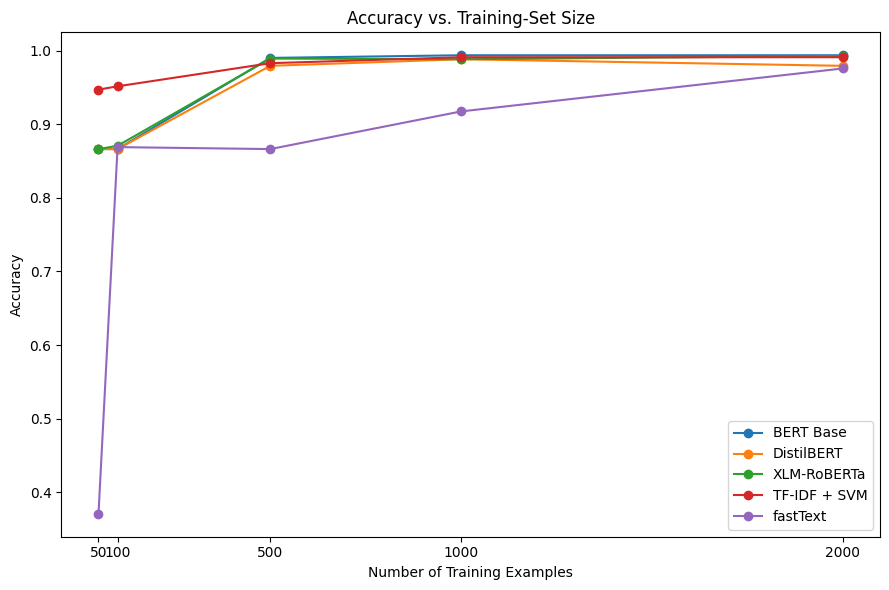

Saved: /content/drive/MyDrive/spam-detection/outputs/experiment_3_training_size_accuracy.png


In [40]:
import matplotlib.pyplot as plt

# Create the training-size accuracy plot.
plt.figure(
    figsize=(9, 6)
)

# Plot one accuracy curve for each model.
for model_name in model_classes:
    model_results = (
        experiment_3_results_df[
            experiment_3_results_df[
                "model"
            ] == model_name
        ]
        .sort_values(
            "training_size"
        )
    )

    plt.plot(
        model_results[
            "training_size"
        ],
        model_results[
            "accuracy"
        ],
        marker="o",
        label=model_name,
    )

# Configure the plot labels and legend.
plt.xlabel(
    "Number of Training Examples"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Accuracy vs. Training-Set Size"
)

plt.xticks(
    TRAINING_SIZES
)

plt.legend()
plt.tight_layout()

# Save the plot to persistent storage.
EXPERIMENT_3_PLOT_PATH = (
    "/content/drive/MyDrive/spam-detection/outputs/"
    "experiment_3_training_size_accuracy.png"
)

plt.savefig(
    EXPERIMENT_3_PLOT_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    EXPERIMENT_3_PLOT_PATH,
)

#### Experiment 3 Interpretation

Accuracy generally improves as the amount of labelled training data increases. The largest gains occur between the smallest training sizes and the medium-sized subsets, showing that the models benefit substantially from having more labelled examples.

BERT Base and XLM-RoBERTa improve sharply by 500 training examples and reach approximately 0.99 accuracy. TF-IDF + SVM performs strongly even with only 50 examples and continues to improve as more data is added. fastText starts substantially lower than the other approaches at 50 examples, but its performance improves considerably as the training set grows.

The trend is not perfectly monotonic for every model. For example, DistilBERT reaches approximately 0.988 accuracy with 1000 examples but decreases slightly at 2000 examples. Small fluctuations of this kind can occur because model training is stochastic. Since the same fixed test set is used at every training size, these differences are not caused by changes in the evaluation data.


Overall, the results show diminishing returns as the training set becomes larger: most models obtain large improvements early and then approach a high-performance plateau.

### 4.4 Experiment 4 — Realistic Class Balance

The fourth experiment evaluates model performance under a more realistic class distribution. Public spam datasets often contain a much larger proportion of spam than would be expected in real carrier traffic, where spam may represent well under 1% of all messages.

To simulate this setting, each fixed test split is modified by keeping all legitimate (`ham`) messages and downsampling only the spam messages until spam represents approximately 1% of the resulting test set. The trained models from Experiment 1 are then evaluated on these new test sets without any retraining.

This experiment is particularly important for spam detection because even a small false-positive rate can become problematic when legitimate messages greatly outnumber spam. The evaluation therefore continues to focus on precision, recall, F1, PR-AUC, and precision at fixed recall rather than relying on accuracy alone.



#### Preparing the Realistic Test Sets

Before evaluating the trained models, the realistic test sets are created and checked to verify that the intended class distribution has been produced correctly.

For each dataset, all legitimate (`ham`) messages from the original fixed test split are retained, while only the spam messages are downsampled. Each resulting test set should therefore contain approximately 1% spam without removing legitimate messages.



In [41]:
# Create realistic test sets with approximately 1% spam.
TARGET_REALISTIC_SPAM_RATIO = 0.01

realistic_test_sets = {}
realistic_balance_rows = []

for dataset_name, (_, test_df) in dataset_splits.items():
    realistic_test_df = create_realistic_test_set(
        test_df,
        target_spam_ratio=TARGET_REALISTIC_SPAM_RATIO,
    )

    realistic_test_sets[dataset_name] = realistic_test_df

    original_ham_count = (
        test_df["label"] == "ham"
    ).sum()

    realistic_ham_count = (
        realistic_test_df["label"] == "ham"
    ).sum()

    realistic_balance_rows.append(
        {
            "dataset": dataset_name,
            "original_test_size": len(test_df),
            "realistic_test_size": len(realistic_test_df),
            "original_spam_ratio": (
                test_df["label"] == "spam"
            ).mean(),
            "realistic_spam_ratio": (
                realistic_test_df["label"] == "spam"
            ).mean(),
            "original_ham_count": original_ham_count,
            "realistic_ham_count": realistic_ham_count,
        }
    )

realistic_balance_df = pd.DataFrame(
    realistic_balance_rows
)

realistic_balance_df

,dataset,original_test_size,realistic_test_size,original_spam_ratio,realistic_spam_ratio,original_ham_count,realistic_ham_count
0,UCI SMS,1114,975,0.133752,0.010256,965,965
1,Turkish SMS,950,447,0.533684,0.008949,443,443
2,YouTube Spam,391,192,0.514066,0.010417,190,190
3,Enron Spam,6743,3342,0.509269,0.009874,3309,3309


#### Realistic Test Set Validation

The realistic test sets achieve spam ratios close to the target value of 1% across all four datasets. The resulting spam ratios are approximately 1.03% for UCI SMS, 0.89% for Turkish SMS, 1.04% for YouTube Spam, and 0.99% for Enron Spam. The small deviations from exactly 1% are expected because the number of retained spam messages must be an integer.

For every dataset, the number of legitimate (`ham`) messages remains unchanged between the original and realistic test sets. This confirms that the class balance adjustment removes only spam messages while preserving all legitimate messages, as required for the realistic class-balance evaluation.


#### Experiment 4 Checkpointing

Experiment 4 reuses the trained model checkpoints from Experiment 1, since the models are evaluated on the realistic test sets without retraining.

The experiment results are saved to Google Drive so that completed evaluations can be preserved and reused if the notebook session is interrupted.


In [42]:
# Define the persistent path for Experiment 4 results.
EXPERIMENT_4_RESULTS_PATH = (
    "/content/drive/MyDrive/spam-detection/outputs/"
    "experiment_4_results.csv"
)

# Ensure the output directory exists.
os.makedirs(
    os.path.dirname(EXPERIMENT_4_RESULTS_PATH),
    exist_ok=True,
)

#### Experiment 4 Results

The models trained during Experiment 1 are evaluated on the realistic test sets created above. No retraining is performed; each model is loaded from its existing dataset-specific checkpoint and evaluated on the corresponding test set with approximately 1% spam.

The same evaluation metrics used in the previous experiments are reported: precision, recall, F1 score, PR-AUC, and precision at the fixed recall target of 0.90. Results are saved incrementally to the persistent Experiment 4 results file.


In [43]:
# Run or resume Experiment 4 using Experiment 1 checkpoints.
experiment_4_results_df = run_realistic_balance_experiment(
    realistic_test_sets,
    model_classes,
    EXPERIMENT_4_RESULTS_PATH,
    EXPERIMENT_1_MODEL_DIR,
)

experiment_4_results_df

Completed Experiment 4 runs: 20/20
Skipping UCI SMS | BERT Base (already completed)
Skipping UCI SMS | DistilBERT (already completed)
Skipping UCI SMS | XLM-RoBERTa (already completed)
Skipping UCI SMS | TF-IDF + SVM (already completed)
Skipping UCI SMS | fastText (already completed)
Skipping Turkish SMS | BERT Base (already completed)
Skipping Turkish SMS | DistilBERT (already completed)
Skipping Turkish SMS | XLM-RoBERTa (already completed)
Skipping Turkish SMS | TF-IDF + SVM (already completed)
Skipping Turkish SMS | fastText (already completed)
Skipping YouTube Spam | BERT Base (already completed)
Skipping YouTube Spam | DistilBERT (already completed)
Skipping YouTube Spam | XLM-RoBERTa (already completed)
Skipping YouTube Spam | TF-IDF + SVM (already completed)
Skipping YouTube Spam | fastText (already completed)
Skipping Enron Spam | BERT Base (already completed)
Skipping Enron Spam | DistilBERT (already completed)
Skipping Enron Spam | XLM-RoBERTa (already completed)
Skipping En

,dataset,model,precision,recall,f1,pr_auc,precision_at_recall
0,UCI SMS,BERT Base,0.714286,1.0,0.833333,1.000000,1.000000
1,UCI SMS,DistilBERT,0.769231,1.0,0.869565,1.000000,1.000000
2,UCI SMS,XLM-RoBERTa,0.909091,1.0,0.952381,0.990455,1.000000
3,UCI SMS,TF-IDF + SVM,0.769231,1.0,0.869565,1.000000,1.000000
4,UCI SMS,fastText,0.833333,1.0,0.909091,0.931346,0.900000
5,Turkish SMS,BERT Base,1.000000,1.0,1.000000,1.000000,1.000000
6,Turkish SMS,DistilBERT,1.000000,1.0,1.000000,1.000000,1.000000
7,Turkish SMS,XLM-RoBERTa,1.000000,1.0,1.000000,1.000000,1.000000
8,Turkish SMS,TF-IDF + SVM,1.000000,1.0,1.000000,1.000000,1.000000
9,Turkish SMS,fastText,0.666667,1.0,0.800000,1.000000,1.000000


#### Experiment 4 Interpretation

The realistic class-balance experiment shows that model performance can change substantially when spam becomes rare, even though the trained models themselves are unchanged.

Recall remains at 1.0 for all evaluated models, meaning that every spam message in the downsampled test sets is detected at the default decision threshold. However, precision decreases considerably for several models once spam represents only about 1% of the evaluation data. This effect is especially visible on the YouTube Spam and Enron Spam datasets.

The decrease in precision is caused by the much larger number of legitimate messages relative to spam. Under this class distribution, even a small number of false positives can become large relative to the number of true spam detections. For example, the realistic YouTube test set contains only two spam messages, so only a few legitimate messages incorrectly classified as spam are sufficient to reduce precision substantially.

The results therefore demonstrate why performance measured on relatively balanced public spam datasets may not directly represent production behavior. In a high-volume carrier setting, false positives become particularly important because legitimate traffic greatly outnumbers spam. Metrics such as precision, PR-AUC, and precision at a fixed recall level are therefore more informative than accuracy alone when evaluating models under realistic spam prevalence.


### 4.5 Experiment 5 — Speed and Model Size

The final experiment compares the computational cost of the five trained spam-detection models.

For each model, CPU inference throughput is measured in messages per second, and the size of the saved model checkpoint is measured on disk. To make the throughput comparison consistent, all models are evaluated on the same batch of 1000 UCI SMS test messages.

Each model is first loaded from its Experiment 1 checkpoint and moved to CPU. A short warm-up is performed before timing,


#### Experiment 5 Benchmark Setup

The UCI SMS test split is used as the common benchmark dataset so that all five models process exactly the same messages.

The first 1000 messages from the fixed UCI SMS test split are used for each timed run. Before timing begins, each model performs a short warm-up on 20 messages. Throughput is then measured over five runs, and the median number of messages processed per second is reported.


In [44]:
# Define the common CPU benchmark configuration.
EXPERIMENT_5_DATASET = "UCI SMS"
EXPERIMENT_5_NUM_MESSAGES = 1000
EXPERIMENT_5_WARMUP_SIZE = 20
EXPERIMENT_5_NUM_RUNS = 5

experiment_5_test_df = dataset_splits[
    EXPERIMENT_5_DATASET
][1]

print("Benchmark dataset:", EXPERIMENT_5_DATASET)
print("Available test messages:", len(experiment_5_test_df))
print("Timed messages per run:", EXPERIMENT_5_NUM_MESSAGES)
print("Warm-up messages:", EXPERIMENT_5_WARMUP_SIZE)
print("Timed runs:", EXPERIMENT_5_NUM_RUNS)

Benchmark dataset: UCI SMS
Available test messages: 1114
Timed messages per run: 1000
Warm-up messages: 20
Timed runs: 5


#### Experiment 5 Checkpointing

Experiment 5 reuses the trained model checkpoints from Experiment 1, since no retraining is required for the speed and model-size measurements.

The benchmark results are saved to Google Drive after each completed model so that completed measurements are preserved if the notebook session is interrupted.


In [45]:
# Define the persistent path for Experiment 5 results.
EXPERIMENT_5_RESULTS_PATH = (
    "/content/drive/MyDrive/spam-detection/outputs/"
    "experiment_5_results.csv"
)

# Ensure the output directory exists.
os.makedirs(
    os.path.dirname(EXPERIMENT_5_RESULTS_PATH),
    exist_ok=True,
)

#### Experiment 5 Results

The five models are benchmarked using their trained Experiment 1 checkpoints. Each checkpoint is loaded without retraining, and transformer models are explicitly moved to CPU before inference.

After a short warm-up, each model processes the same batch of 1000 UCI SMS test messages five times. The median CPU throughput across the five timed runs is reported together with the total size of the saved model checkpoint on disk.


In [46]:
# Run or resume Experiment 5 using Experiment 1 checkpoints.
experiment_5_results_df = run_speed_size_experiment(
    benchmark_df=experiment_5_test_df,
    model_classes=model_classes,
    results_path=EXPERIMENT_5_RESULTS_PATH,
    model_dir=EXPERIMENT_1_MODEL_DIR,
    dataset_name=EXPERIMENT_5_DATASET,
    num_messages=EXPERIMENT_5_NUM_MESSAGES,
    warmup_size=EXPERIMENT_5_WARMUP_SIZE,
    num_runs=EXPERIMENT_5_NUM_RUNS,
)

experiment_5_results_df

Completed Experiment 5 runs: 5/5
Skipping BERT Base (already completed)
Skipping DistilBERT (already completed)
Skipping XLM-RoBERTa (already completed)
Skipping TF-IDF + SVM (already completed)
Skipping fastText (already completed)


,dataset,model,num_messages,num_runs,messages_per_second,model_size_mb
0,UCI SMS,BERT Base,1000,5,1.878178,418.349696
1,UCI SMS,DistilBERT,1000,5,3.779796,256.104673
2,UCI SMS,XLM-RoBERTa,1000,5,1.251214,1076.988709
3,UCI SMS,TF-IDF + SVM,1000,5,2198.916425,2.598349
4,UCI SMS,fastText,1000,5,8268.812684,768.318202


#### Experiment 5 Interpretation

The CPU benchmark shows a large efficiency difference between the transformer and non-transformer models. The transformer models processed only around 1–4 messages per second, with XLM-RoBERTa being both the slowest and largest model. DistilBERT was the most efficient transformer, running about twice as fast as BERT Base while also using less disk space.

The non-transformer models were much faster. fastText achieved the highest throughput at over 8,000 messages per second, although its saved model was relatively large. TF-IDF + SVM provided a different trade-off: it processed more than 2,000 messages per second while requiring only about 2.6 MB of disk space.

These results show that inference quality alone is not enough when considering a high-volume production setting. Model speed and storage requirements differ substantially even when the models are evaluated on exactly the same messages.
